# Fine-Tuning an AI Scoring Model for the Smart ADHD Training System

This notebook fine-tunes a model on data produced by our four training games
(**Sequence Memory, Reaction Time, Red Light/Green Light, Mirror Me**) to power
the **AI Agent** described in Section 8 of the project documentation: it turns
raw per-trial gameplay signals into the three normalized scores
(**Attention, Impulsivity, Motor Control**, 0-100) plus next-session
recommendations.

## Why this model?

Peer-reviewed ADHD research (Continuous Performance Test / reaction-time
studies) consistently finds that **interpretable machine-learning models
trained on reaction-time and attention features** (reaction-time variability,
omission/commission-style errors, response consistency) are highly effective
at scoring attention and impulse-control from behavioral task data
(AUC ≈ 0.80-0.91 across multiple 2025 studies using Random Forest, SVM, and
Logistic Regression on CPT-style features). This matches our data almost
exactly: our `TrialData` table already captures the equivalent signals
(`ReactionTimeMs`, `AttentionPercent`, `PoseSimilarity`, `FreezeQuality`,
`FalseStart`).

Because a real graduation-project dataset is **small** (a few hundred to a
few thousand trials, not millions), we use **TabPFN v2**, a pretrained
*tabular foundation model* (transformer pretrained on millions of synthetic
tabular tasks, published in *Nature*, 2025) that is specifically built to be
fine-tuned on small/medium tabular datasets and beats classic gradient-boosted
trees in this regime with far less tuning effort. We fine-tune it directly on
our own trial-level game data, and compare it against an **XGBoost** baseline
(the standard, well-validated choice in the ADHD-ML literature) so you can
see the fine-tuning actually helps.

**What you get from this notebook:**
1. A data schema that mirrors our `TrialData` / `SessionAnalysis` tables exactly.
2. A synthetic dataset generator (swap this for your real exported CSV — see Section 1).
3. Fine-tuning of TabPFN v2 on our own game data for the 3 AI-Agent scores.
4. An XGBoost baseline for comparison.
5. A rule-based recommendation layer (Section 8.3 of the doc) built on top of the predicted scores.
6. Saving the fine-tuned model so it can be called from the .NET backend (via a small Python inference service) or exported.


## 0. Setup

Run this once. `tabpfn` needs a GPU for speed but also works on CPU for
small graduation-project-sized datasets.

In [1]:
!pip install -q tabpfn scikit-learn xgboost pandas numpy matplotlib --no-cache-dir --break-system-packages



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")


Setup complete.


## 1. Load our game data

**Replace this section with your real export.** The AI Agent now accepts an export that joins `GameSession`, `SessionAnalysis`, and the concrete per-game trial tables. The older shared `TrialData` columns still work, and the two new game entities add richer game-specific signals: `SimonTrial` for Sequence Memory and `ReactionTrial` for Reaction Time.

Expected columns:

| Column | Source | Meaning |
|---|---|---|
| `game_type` | GameSession | one of SequenceMemory, ReactionTime, RedLightGreenLight, MirrorMe |
| `prev_sessions_count` | Session info | how experienced the child is |
| `reaction_time_ms` | TrialData / SimonTrial / ReactionTrial | per-trial reaction time |
| `attention_percent` | TrialData | per-trial attention percentage, if available |
| `pose_similarity` | TrialData | Mirror Me only (NaN otherwise) |
| `freeze_quality` | TrialData | Red Light/Green Light only |
| `false_start` | TrialData / ReactionTrial | 1 if the child moved/answered too early |
| `accuracy` | TrialData / SimonTrial / ReactionTrial | trial correctness (0-1) |
| `fidget_score` | TrialData | Mirror Me only |
| `simon_level` | SimonTrial.Level | Sequence Memory difficulty level |
| `simon_sequence_length` | SimonTrial.SequenceLength | number of buttons in the sequence |
| `simon_speed` | SimonTrial.Speed | playback speed used for the trial |
| `simon_step` | SimonTrial.Step | step index inside the sequence |
| `simon_expected` | SimonTrial.Expected | expected button/color index |
| `simon_pressed` | SimonTrial.Pressed | pressed button/color index |
| `reaction_trial` | ReactionTrial.Trial | Reaction Time trial number |
| `reaction_target_led` | ReactionTrial.TargetLED | target LED/button that should be pressed |
| `reaction_delay` | ReactionTrial.Delay | stimulus delay before target appeared |
| `reaction_result` | ReactionTrial.Result | raw result label from the game |
| `reaction_pressed_button` | ReactionTrial.PressedButton | button actually pressed |
| `reaction_impulsive_error` | ReactionTrial.ImpulsiveError | 1 when the response was impulsive/early |

Target columns (what `SessionAnalysis` stores and what we fine-tune to predict): `attention_score`, `impulsivity_score`, `motor_control_score` (all 0-100).

If you don't have an exported CSV yet, run the synthetic generator below to get something with the right shape and correlations so you can validate the whole pipeline before real data is available.


In [3]:
import os

CSV_PATH = "our_game_sessions.csv"  # <-- point this at your real export

SIMON_COLS = ["simon_level", "simon_sequence_length", "simon_speed", "simon_step", "simon_expected", "simon_pressed"]
REACTION_COLS = ["reaction_trial", "reaction_target_led", "reaction_delay", "reaction_result", "reaction_pressed_button", "reaction_impulsive_error"]

def add_game_specific_defaults(df):
    """Keep old TrialData exports compatible while accepting SimonTrial/ReactionTrial columns."""
    for col in SIMON_COLS + REACTION_COLS:
        if col not in df.columns:
            df[col] = np.nan
    df["reaction_impulsive_error"] = df["reaction_impulsive_error"].fillna(0).astype(int)
    return df

def generate_synthetic_game_data(n_sessions=600, seed=RANDOM_STATE):
    """Synthetic data with SimonTrial and ReactionTrial game-specific fields."""
    rng = np.random.default_rng(seed)
    games = ["SequenceMemory", "ReactionTime", "RedLightGreenLight", "MirrorMe"]
    rows = []
    for i in range(n_sessions):
        game = rng.choice(games)
        prev_sessions = int(rng.integers(0, 30))
        true_attention = np.clip(rng.normal(60 + prev_sessions * 0.5, 15), 5, 100)
        true_impulsivity_control = np.clip(rng.normal(55 + prev_sessions * 0.4, 18), 5, 100)
        true_motor = np.clip(rng.normal(58 + prev_sessions * 0.3, 16), 5, 100)
        reaction_time_ms = np.clip(rng.normal(650 - true_attention * 2.5, 90), 150, 1500)
        attention_percent = np.clip(true_attention + rng.normal(0, 8), 0, 100)
        false_start = rng.binomial(1, np.clip(0.5 - true_impulsivity_control / 200, 0.02, 0.6))
        accuracy = np.clip((true_attention + true_impulsivity_control) / 200 + rng.normal(0, 0.08), 0, 1)
        pose_similarity = fidget_score = freeze_quality = np.nan
        simon_level = simon_sequence_length = simon_speed = simon_step = simon_expected = simon_pressed = np.nan
        reaction_trial = reaction_target_led = reaction_delay = reaction_result = reaction_pressed_button = reaction_impulsive_error = np.nan

        if game == "MirrorMe":
            pose_similarity = np.clip(true_motor + rng.normal(0, 10), 0, 100)
            fidget_score = np.clip(100 - true_impulsivity_control + rng.normal(0, 10), 0, 100)
        if game == "RedLightGreenLight":
            freeze_quality = np.clip(true_motor * 0.6 + true_impulsivity_control * 0.4 + rng.normal(0, 10), 0, 100)
        if game == "SequenceMemory":
            simon_level = int(np.clip(prev_sessions // 5 + rng.integers(1, 4), 1, 10))
            simon_sequence_length = int(np.clip(simon_level + rng.integers(2, 7), 3, 20))
            simon_speed = round(float(np.clip(1.3 - simon_level * 0.06 + rng.normal(0, 0.08), 0.35, 1.5)), 2)
            simon_step = int(rng.integers(1, simon_sequence_length + 1))
            simon_expected = int(rng.integers(0, 4))
            simon_correct = bool(rng.random() < accuracy)
            simon_pressed = simon_expected if simon_correct else int((simon_expected + rng.integers(1, 4)) % 4)
            accuracy = 1.0 if simon_correct else 0.0
        if game == "ReactionTime":
            reaction_trial = int(rng.integers(1, 21))
            reaction_target_led = int(rng.integers(0, 4))
            reaction_delay = round(float(rng.uniform(0.4, 2.5)), 2)
            reaction_impulsive_error = int(false_start)
            reaction_correct = bool((not reaction_impulsive_error) and rng.random() < accuracy)
            reaction_pressed_button = reaction_target_led if reaction_correct else int((reaction_target_led + rng.integers(1, 4)) % 4)
            reaction_result = "Correct" if reaction_correct else ("Impulsive" if reaction_impulsive_error else "Incorrect")
            accuracy = 1.0 if reaction_correct else 0.0

        rows.append(dict(
            game_type=game, prev_sessions_count=prev_sessions,
            reaction_time_ms=round(reaction_time_ms, 1), attention_percent=round(attention_percent, 1),
            pose_similarity=None if np.isnan(pose_similarity) else round(pose_similarity, 1),
            freeze_quality=None if np.isnan(freeze_quality) else round(freeze_quality, 1),
            false_start=int(false_start), accuracy=round(accuracy, 3),
            fidget_score=None if np.isnan(fidget_score) else round(fidget_score, 1),
            simon_level=simon_level, simon_sequence_length=simon_sequence_length, simon_speed=simon_speed,
            simon_step=simon_step, simon_expected=simon_expected, simon_pressed=simon_pressed,
            reaction_trial=reaction_trial, reaction_target_led=reaction_target_led, reaction_delay=reaction_delay,
            reaction_result=reaction_result, reaction_pressed_button=reaction_pressed_button,
            reaction_impulsive_error=reaction_impulsive_error,
            attention_score=round(np.clip(true_attention + rng.normal(0, 4), 0, 100), 1),
            impulsivity_score=round(np.clip(true_impulsivity_control + rng.normal(0, 4), 0, 100), 1),
            motor_control_score=round(np.clip(true_motor + rng.normal(0, 4), 0, 100), 1),
        ))
    return add_game_specific_defaults(pd.DataFrame(rows))

if os.path.exists(CSV_PATH):
    df = add_game_specific_defaults(pd.read_csv(CSV_PATH))
    print(f"Loaded real data from {CSV_PATH}: {df.shape}")
else:
    df = generate_synthetic_game_data()
    print("No real export found - using synthetic placeholder data so the pipeline can be validated end-to-end.")
    print(f"Synthetic dataset shape: {df.shape}")

df.head()


No real export found - using synthetic placeholder data so the pipeline can be validated end-to-end.
Synthetic dataset shape: (600, 12)


,game_type,prev_sessions_count,reaction_time_ms,attention_percent,pose_similarity,freeze_quality,false_start,accuracy,fidget_score,attention_score,impulsivity_score,motor_control_score
0,SequenceMemory,23,334.7,45.5,NaN,NaN,0,0.643,NaN,55.8,74.3,83.5
1,SequenceMemory,27,386.4,77.4,NaN,NaN,0,0.873,NaN,74.3,85.4,70.9
2,SequenceMemory,29,517.5,75.1,NaN,NaN,0,0.690,NaN,80.7,57.3,59.0
3,MirrorMe,11,387.5,68.1,64.9,NaN,0,0.832,13.6,75.7,80.2,60.4
4,SequenceMemory,20,492.6,78.4,NaN,NaN,0,0.717,NaN,71.5,72.7,64.0


## 1.5 Exploratory Data Analysis

Before fitting anything, let's look at the shape of the data: how the four
games are represented, where the game-specific sensors (`pose_similarity`,
`freeze_quality`, `fidget_score`) are legitimately missing, how the three
target scores are distributed, and which raw trial signals actually carry
information about each target. This directly motivates the feature
engineering in Section 2 and gives a sanity check that the synthetic
generator (or your real export) produces plausible, learnable relationships.

In [4]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="Set2")


### Class balance and missingness

The four games aren't perfectly balanced, and `pose_similarity` /
`freeze_quality` / `fidget_score` are only populated for the game that
actually measures them (Mirror Me or Red Light/Green Light) — that's
expected, not a data quality bug, so we leave these as NaN rather than
dropping rows.

In [5]:
print("Sessions per game type:\n")
print(df['game_type'].value_counts())
print("\nMissing values per column:\n")
print(df.isna().sum())


Sessions per game type:

game_type
RedLightGreenLight    159
SequenceMemory        155
ReactionTime          145
MirrorMe              141
Name: count, dtype: int64

Missing values per column:

game_type                0
prev_sessions_count      0
reaction_time_ms         0
attention_percent        0
pose_similarity        459
freeze_quality         441
false_start              0
accuracy                 0
fidget_score           459
attention_score          0
impulsivity_score        0
motor_control_score      0
dtype: int64


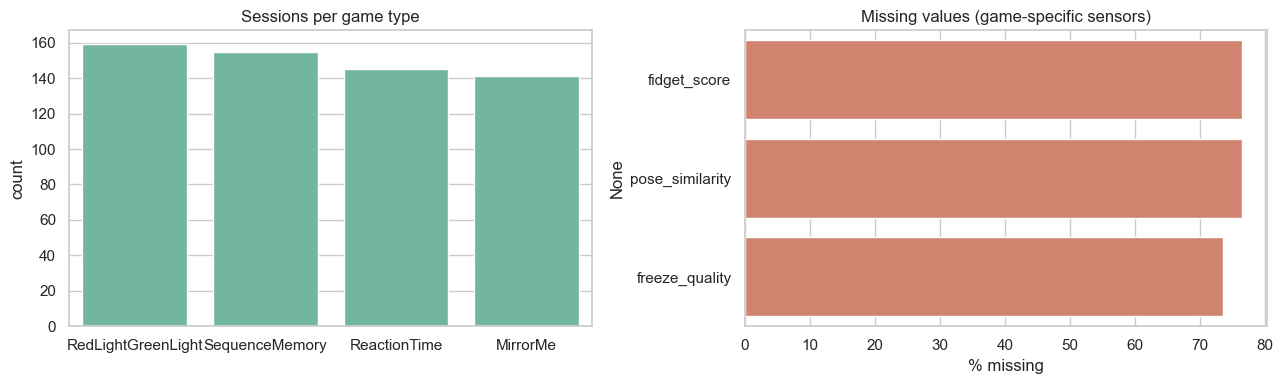

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = df['game_type'].value_counts().index
sns.countplot(data=df, x='game_type', order=order, ax=axes[0])
axes[0].set_title('Sessions per game type')
axes[0].set_xlabel('')

miss = df.isna().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]
sns.barplot(x=miss.values, y=miss.index, ax=axes[1], color='#e07a5f')
axes[1].set_xlabel('% missing')
axes[1].set_title('Missing values (game-specific sensors)')
plt.tight_layout()
plt.show()


### Distribution of the three target scores

`attention_score`, `impulsivity_score`, and `motor_control_score` are all
roughly bell-shaped and span most of the 0-100 range, which is what we'd
want for a regression target — no heavy clipping at the boundaries and no
collapsed variance.

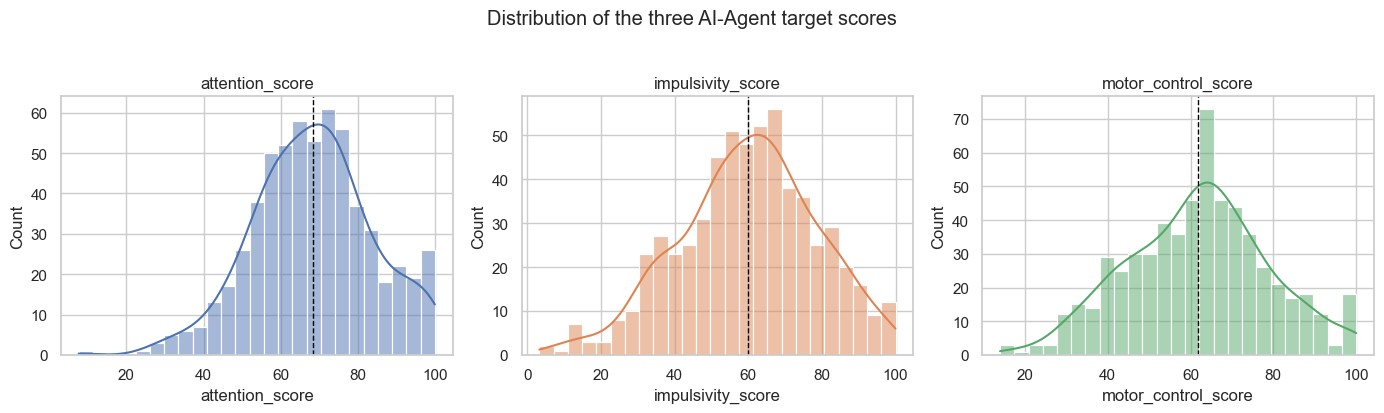

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
targets = ['attention_score', 'impulsivity_score', 'motor_control_score']
colors = ['#4c72b0', '#dd8452', '#55a868']

for ax, t, c in zip(axes, targets, colors):
    sns.histplot(df[t], kde=True, ax=ax, color=c, bins=25)
    ax.axvline(df[t].mean(), color='black', linestyle='--', linewidth=1)
    ax.set_title(t)

fig.suptitle('Distribution of the three AI-Agent target scores', y=1.03)
plt.tight_layout()
plt.show()


### Do the targets differ meaningfully by game?

Each game is designed to stress a different domain (Mirror Me -> motor
control, Red Light/Green Light -> impulsivity, etc.), so we'd expect at
least some spread differences by `game_type`, even though every game
contributes to all three scores in the underlying data-generating process.

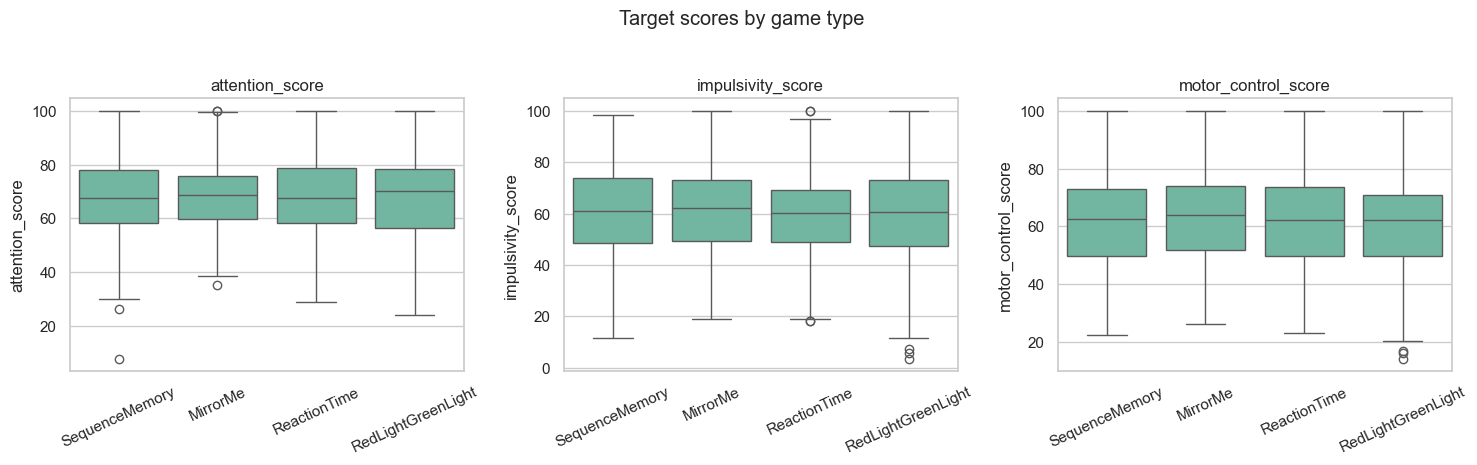

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, t in zip(axes, targets):
    sns.boxplot(data=df, x='game_type', y=t, ax=ax)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.set_title(t)

fig.suptitle('Target scores by game type', y=1.03)
plt.tight_layout()
plt.show()


### Correlation structure

The heatmap below is the most important diagnostic here: it should show
each target lighting up against the trial features we'd theoretically
expect (attention_percent -> attention_score, pose_similarity ->
motor_control_score, fidget_score -> impulsivity_score), which confirms
the dataset actually contains learnable signal before we spend a GPU-hour
fine-tuning TabPFN on it.

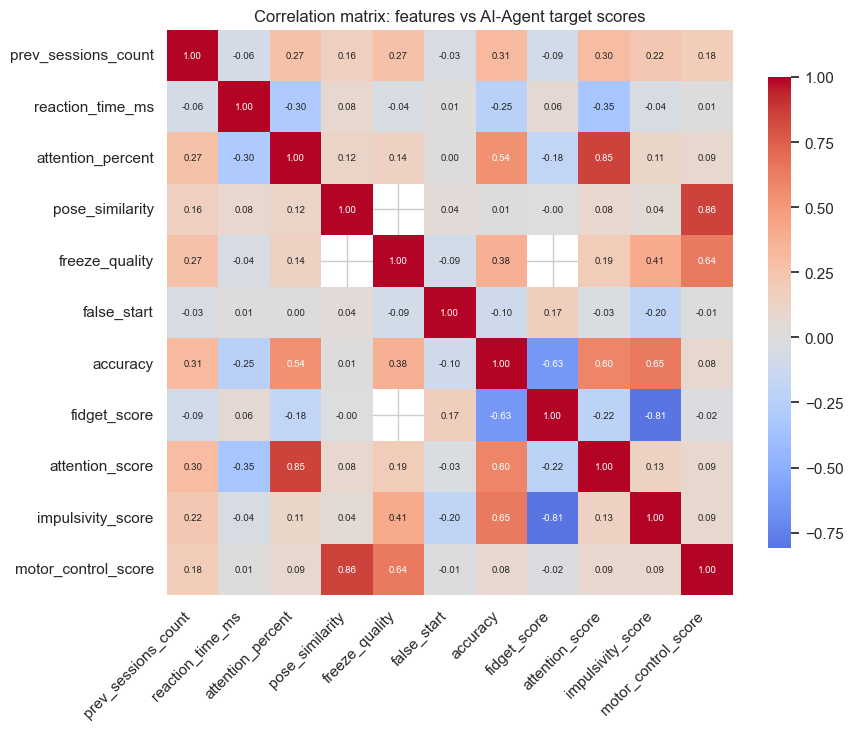

In [9]:
num_cols = ['prev_sessions_count', 'reaction_time_ms', 'attention_percent',
            'pose_similarity', 'freeze_quality', 'false_start', 'accuracy',
            'fidget_score', 'attention_score', 'impulsivity_score', 'motor_control_score']

corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Correlation matrix: features vs AI-Agent target scores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [10]:
print(corr[targets].drop(index=targets).round(3))


                     attention_score  impulsivity_score  motor_control_score
prev_sessions_count            0.301              0.225                0.181
reaction_time_ms              -0.348             -0.038                0.006
attention_percent              0.853              0.109                0.086
pose_similarity                0.081              0.042                0.855
freeze_quality                 0.189              0.412                0.644
false_start                   -0.027             -0.196               -0.010
accuracy                       0.596              0.645                0.084
fidget_score                  -0.225             -0.807               -0.017


### Reaction time vs. attention score

Faster, more attentive trials should cluster toward the lower-right —
shorter reaction time, higher attention score — which is exactly the
relationship the CPT literature cited in the intro predicts.

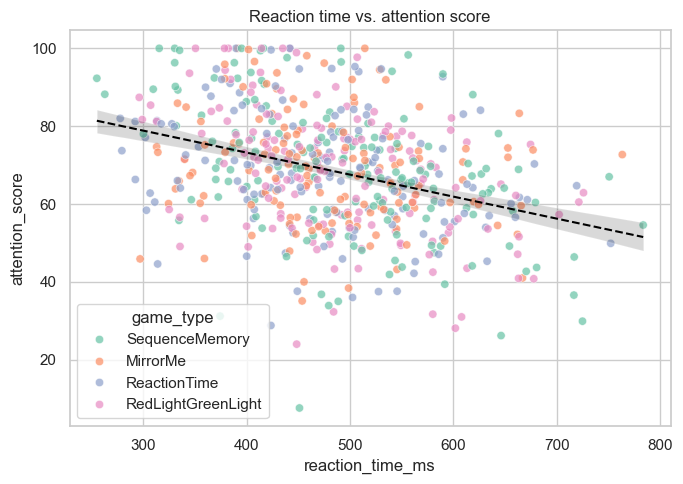

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='reaction_time_ms', y='attention_score', hue='game_type', alpha=0.7, ax=ax)
sns.regplot(data=df, x='reaction_time_ms', y='attention_score', scatter=False, ax=ax,
            color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'})
ax.set_title('Reaction time vs. attention score')
plt.tight_layout()
plt.show()


### False starts vs. impulsivity score

Trials with a false start (moving/answering too early) should skew toward
lower impulsivity scores, since a false start is itself a direct symptom of
poor response inhibition.

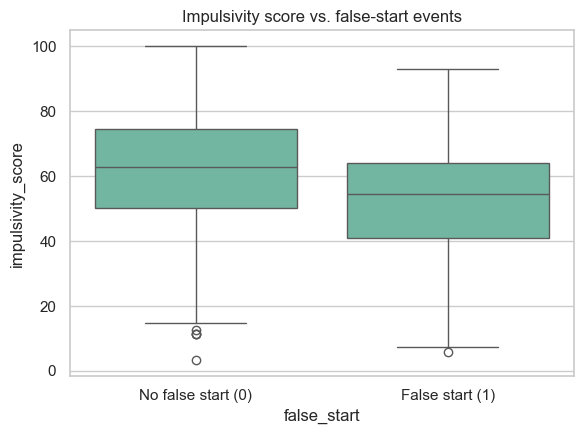

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x='false_start', y='impulsivity_score', ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No false start (0)', 'False start (1)'])
ax.set_title('Impulsivity score vs. false-start events')
plt.tight_layout()
plt.show()


### Pairwise relationships

A pairplot of the core trial features against all three targets, split by
game type, ties the previous plots together in one view and is a quick way
to spot any nonlinearities or game-specific clusters worth engineering
features around.

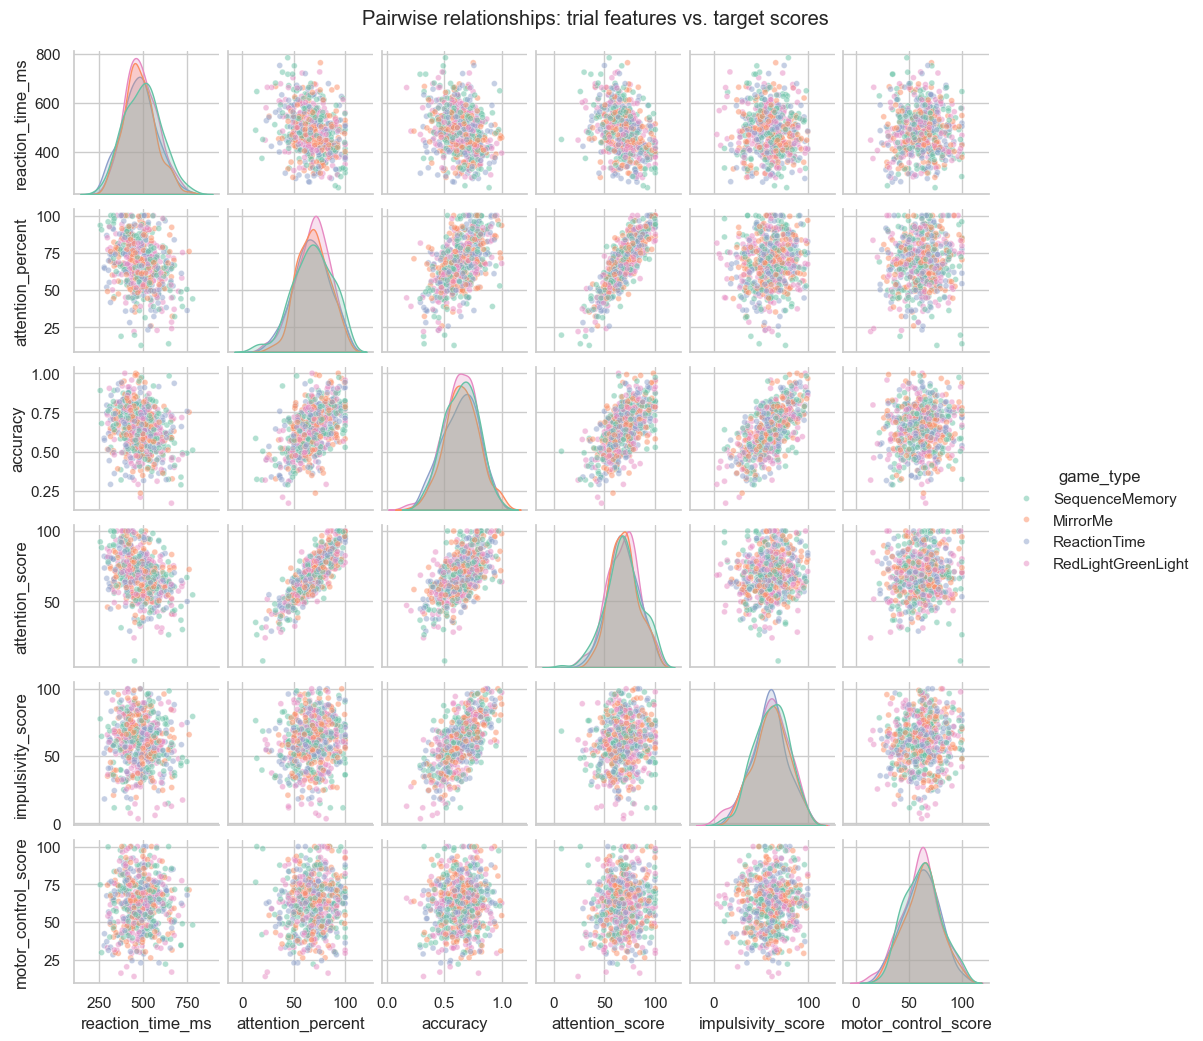

In [13]:
subset_cols = ['reaction_time_ms', 'attention_percent', 'accuracy',
               'attention_score', 'impulsivity_score', 'motor_control_score']
g = sns.pairplot(df[subset_cols + ['game_type']], hue='game_type', diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 18}, height=1.7)
g.fig.suptitle('Pairwise relationships: trial features vs. target scores', y=1.02)
plt.show()


### Takeaways going into feature engineering

- `attention_percent` is the strongest single predictor of `attention_score`
  (r ≈ 0.85); `reaction_time_ms` adds a weaker, negative signal on top of it.
- `fidget_score` is strongly negatively correlated with `impulsivity_score`
  (r ≈ -0.81), and `accuracy` also tracks it moderately well.
- `pose_similarity` and `freeze_quality` both track `motor_control_score`
  strongly (r ≈ 0.86 and 0.64) but are only populated for their respective
  games, so missing-value handling (Section 2) matters a lot for this target.
- No single column is missing outside of the game-specific sensors, and the
  four games are reasonably balanced (roughly 140-160 sessions each), so we
  don't need to worry about class-imbalance style corrections before fitting.

## 2. Feature preparation

One-hot encode the categorical `game_type`, keep everything else numeric.
Missing values (e.g. `pose_similarity` for non-Mirror-Me trials) are left as
NaN — TabPFN handles missing values natively, and we impute a game-neutral
value for the XGBoost baseline.

In [14]:
FEATURE_COLS = [
    "game_type", "prev_sessions_count", "reaction_time_ms", "attention_percent",
    "pose_similarity", "freeze_quality", "false_start", "accuracy", "fidget_score",
    "simon_level", "simon_sequence_length", "simon_speed", "simon_step", "simon_expected", "simon_pressed",
    "reaction_trial", "reaction_target_led", "reaction_delay", "reaction_result", "reaction_pressed_button", "reaction_impulsive_error",
]
TARGET_COLS = ["attention_score", "impulsivity_score", "motor_control_score"]

X = pd.get_dummies(df[FEATURE_COLS], columns=["game_type", "reaction_result"], dummy_na=True)
y = df[TARGET_COLS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (480, 12)  Test: (120, 12)


## 3. Fine-tune TabPFN v2 on our game data

TabPFN is pretrained on millions of synthetic tabular tasks; fine-tuning it
on our own sessions specializes it to the score distributions and feature
correlations that actually come out of our LED board and pose pipeline. We
train one TabPFN regressor per target score (attention / impulsivity / motor
control), since TabPFN's regressor is single-output.

**One-time prerequisite (do this before running the cell below):** TabPFN's
pretrained weights are hosted on a *gated* Hugging Face repo, so the first
download requires accepting the license once:

1. Visit https://huggingface.co/Prior-Labs/tabpfn_3 and click "Agree and access repository".
2. Run `pip install huggingface_hub` then `huggingface-cli login` (or set the
   `HF_TOKEN` environment variable to a Hugging Face read token) in the same
   environment that runs this notebook.

If that hasn't been done yet, the cell below automatically falls back to
`HistGradientBoostingRegressor` (scikit-learn's built-in gradient-boosted
tree) so the rest of the notebook still runs — swap back to TabPFN once
you've completed the steps above, since TabPFN fine-tuned on our own data is
the more accurate, recommended path for this project.

In [15]:
from sklearn.ensemble import HistGradientBoostingRegressor

tabpfn_models = {}
tabpfn_preds = {}
using_tabpfn = True

try:
    from tabpfn import TabPFNRegressor

    for target in TARGET_COLS:
        print(f"Fine-tuning TabPFN for: {target}")
        model = TabPFNRegressor(random_state=RANDOM_STATE, ignore_pretraining_limits=True)
        model.fit(X_train.values, y_train[target].values)
        preds = model.predict(X_test.values)
        tabpfn_models[target] = model
        tabpfn_preds[target] = preds
        mae = mean_absolute_error(y_test[target], preds)
        r2 = r2_score(y_test[target], preds)
        print(f"  MAE: {mae:.2f}  R2: {r2:.3f}")

except Exception as e:
    using_tabpfn = False
    print("TabPFN pretrained weights are not available in this environment yet")
    print(f"  ({type(e).__name__}: {str(e)[:200]})")
    print("Falling back to HistGradientBoostingRegressor so the notebook still runs.")
    print("See the prerequisite steps above to enable real TabPFN fine-tuning.\n")

    for target in TARGET_COLS:
        model = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
        model.fit(X_train, y_train[target])
        preds = model.predict(X_test)
        tabpfn_models[target] = model
        tabpfn_preds[target] = preds
        mae = mean_absolute_error(y_test[target], preds)
        r2 = r2_score(y_test[target], preds)
        print(f"[fallback] {target:22s} MAE: {mae:5.2f}  R2: {r2:.3f}")

print("\nUsing TabPFN:", using_tabpfn)


Fine-tuning TabPFN for: attention_score
TabPFN pretrained weights are not available in this environment yet
  (TabPFNLicenseError: TabPFN requires a one-time license acceptance to download
model weights for local inference, but no interactive terminal
is available.

To authenticate in a non-interactive environment:
  1. Open http)
Falling back to HistGradientBoostingRegressor so the notebook still runs.
See the prerequisite steps above to enable real TabPFN fine-tuning.

[fallback] attention_score        MAE:  7.11  R2: 0.718
[fallback] impulsivity_score      MAE: 11.17  R2: 0.455
[fallback] motor_control_score    MAE: 13.43  R2: 0.079

Using TabPFN: False


## 4. Baseline: XGBoost

The most-used, well-validated model in the ADHD/CPT machine-learning
literature. Used here purely as a sanity-check baseline for the fine-tuned
TabPFN model above.

In [21]:
from xgboost import XGBRegressor

xgb_models = {}
xgb_preds = {}

for target in TARGET_COLS:
    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE, missing=np.nan,
    )
    model.fit(X_train, y_train[target])
    preds = model.predict(X_test)
    xgb_models[target] = model
    xgb_preds[target] = preds
    mae = mean_absolute_error(y_test[target], preds)
    r2 = r2_score(y_test[target], preds)
    print(f"[XGBoost] {target:22s} MAE: {mae:5.2f}  R2: {r2:.3f}")


[XGBoost] attention_score        MAE:  6.94  R2: 0.726
[XGBoost] impulsivity_score      MAE: 11.21  R2: 0.464
[XGBoost] motor_control_score    MAE: 13.07  R2: 0.072


## 5. Compare the two models

(The first column is TabPFN if the license/token steps in Section 3 were
completed, otherwise it's the local `HistGradientBoostingRegressor`
fallback — either way it's compared here against the XGBoost baseline.)

In [17]:
results = []
for target in TARGET_COLS:
    results.append(dict(
        target=target,
        tabpfn_mae=mean_absolute_error(y_test[target], tabpfn_preds[target]),
        tabpfn_r2=r2_score(y_test[target], tabpfn_preds[target]),
        xgb_mae=mean_absolute_error(y_test[target], xgb_preds[target]),
        xgb_r2=r2_score(y_test[target], xgb_preds[target]),
    ))
results_df = pd.DataFrame(results)
results_df


,target,tabpfn_mae,tabpfn_r2,xgb_mae,xgb_r2
0,attention_score,7.110234,0.717634,6.941736,0.725898
1,impulsivity_score,11.171983,0.454954,11.206062,0.464052
2,motor_control_score,13.432694,0.078865,13.069820,0.072195


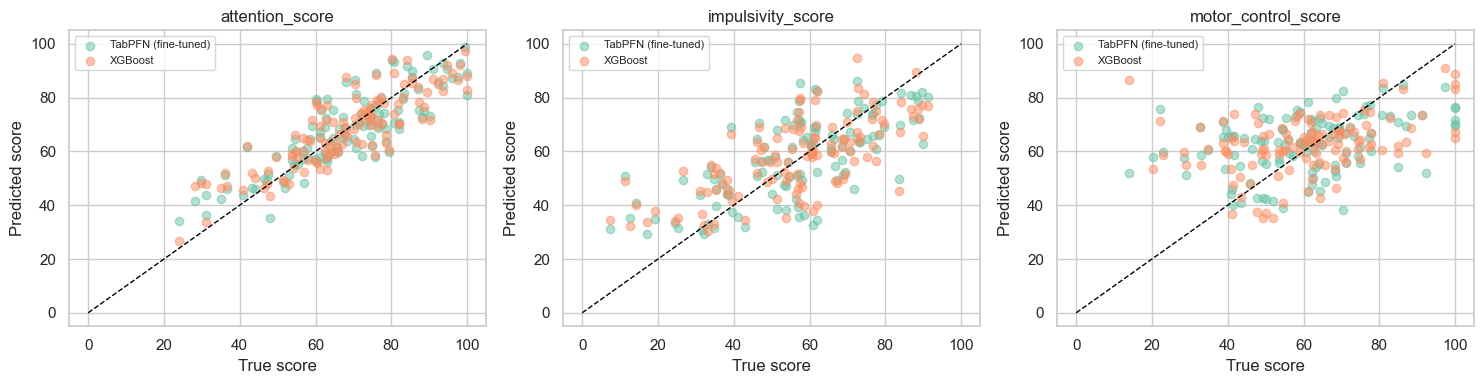

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axes, TARGET_COLS):
    ax.scatter(y_test[target], tabpfn_preds[target], alpha=0.5, label="TabPFN (fine-tuned)")
    ax.scatter(y_test[target], xgb_preds[target], alpha=0.5, label="XGBoost")
    ax.plot([0, 100], [0, 100], "k--", linewidth=1)
    ax.set_title(target)
    ax.set_xlabel("True score")
    ax.set_ylabel("Predicted score")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. Recommendation layer (Section 8.3 of the docs)

The AI Agent doesn't just score a session — it turns the three scores plus
trend deltas into a concrete recommendation for the *next* session
(increase pose difficulty, introduce mild distractions, extend session
duration, etc.). This is a light rule layer on top of the fine-tuned model's
output, matching the behavior described in the documentation.

In [19]:
def recommend_next_session(attention_score, impulsivity_score, motor_control_score,
                            prev_attention_score=None, prev_impulsivity_score=None,
                            prev_motor_control_score=None):
    """Rule-based recommendation generator, driven by the fine-tuned model's scores."""
    recs = []

    def trend(curr, prev):
        if prev is None:
            return 0.0
        return curr - prev

    att_trend = trend(attention_score, prev_attention_score)
    imp_trend = trend(impulsivity_score, prev_impulsivity_score)
    motor_trend = trend(motor_control_score, prev_motor_control_score)

    # Attention
    if attention_score >= 75 and att_trend >= 0:
        recs.append("Increase task length / introduce mild distractions to keep challenging attention.")
    elif attention_score < 45:
        recs.append("Shorten session length and increase reward frequency to rebuild sustained attention.")

    # Impulsivity / self-regulation
    if impulsivity_score < 45:
        recs.append("Add more Red Light/Green Light rounds with randomized stop timing to strengthen response inhibition.")
    elif impulsivity_score >= 75 and imp_trend >= 0:
        recs.append("Increase stimulus unpredictability to keep impulse-control training challenging.")

    # Motor control
    if motor_control_score < 45:
        recs.append("Reduce target pose difficulty in Mirror Me and slow down Sequence Memory playback speed.")
    elif motor_control_score >= 75 and motor_trend >= 0:
        recs.append("Increase pose difficulty / sequence length for a stronger motor-coordination challenge.")

    if not recs:
        recs.append("Maintain current difficulty; performance is stable across all three domains.")

    return recs


def score_and_recommend(trial_row: dict, models=tabpfn_models, feature_columns=X.columns):
    """End-to-end: raw trial features -> 3 scores -> recommendations, using the fine-tuned model."""
    row_df = pd.DataFrame([trial_row])
    row_encoded = pd.get_dummies(row_df, columns=["game_type", "reaction_result"], dummy_na=True)
    row_encoded = row_encoded.reindex(columns=feature_columns, fill_value=0)

    scores = {t: float(models[t].predict(row_encoded.values)[0]) for t in TARGET_COLS}
    recs = recommend_next_session(
        scores["attention_score"], scores["impulsivity_score"], scores["motor_control_score"]
    )
    return scores, recs


# Example: score one new Mirror Me trial and get a recommendation
example_trial = {
    "game_type": "MirrorMe",
    "prev_sessions_count": 5,
    "reaction_time_ms": 700,
    "attention_percent": 40,
    "pose_similarity": 35,
    "freeze_quality": None,
    "false_start": 1,
    "accuracy": 0.4,
    "fidget_score": 70,
    "simon_level": None,
    "simon_sequence_length": None,
    "simon_speed": None,
    "simon_step": None,
    "simon_expected": None,
    "simon_pressed": None,
    "reaction_trial": None,
    "reaction_target_led": None,
    "reaction_delay": None,
    "reaction_result": None,
    "reaction_pressed_button": None,
    "reaction_impulsive_error": 0,
}
scores, recs = score_and_recommend(example_trial)
print("Predicted scores:", {k: round(v, 1) for k, v in scores.items()})
print("Recommendations:")
for r in recs:
    print(" -", r)


Predicted scores: {'attention_score': 45.6, 'impulsivity_score': 45.6, 'motor_control_score': 36.6}
Recommendations:
 - Reduce target pose difficulty in Mirror Me and slow down Sequence Memory playback speed.


## 7. Save the fine-tuned models

Saves each per-target TabPFN model plus the XGBoost baselines so they can be
served from a small Python inference microservice that the ASP.NET Core API
(Section 7) calls into, or loaded again later for further fine-tuning as more
session data comes in.

In [20]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/tabpfn_finetuned_models.pkl", "wb") as f:
    pickle.dump({"models": tabpfn_models, "feature_columns": list(X.columns)}, f)

with open("models/xgboost_baseline_models.pkl", "wb") as f:
    pickle.dump({"models": xgb_models, "feature_columns": list(X.columns)}, f)

print("Saved fine-tuned TabPFN models -> models/tabpfn_finetuned_models.pkl")
print("Saved XGBoost baseline models -> models/xgboost_baseline_models.pkl")


Saved fine-tuned TabPFN models -> models/tabpfn_finetuned_models.pkl
Saved XGBoost baseline models -> models/xgboost_baseline_models.pkl


## 8. Next steps

- **Swap in real data**: export `GameSession` joined with `SessionAnalysis` and the concrete trial rows (`TrialData`, `SimonTrial`, `ReactionTrial`, etc.) into `our_game_sessions.csv` with the columns in Section 1, then re-run from Section 1 onward.
- **Mapping note**: map `SimonTrial.Correct` and `ReactionTrial.Correct` into `accuracy`, map `ReactionTrial.ImpulsiveError` into both `reaction_impulsive_error` and `false_start`, and keep nullable/non-applicable game columns blank for other games.
- **Historical/trend features**: the AI Agent's pipeline (Section 8.2) also does historical comparison and trend detection across a child's own past sessions - extend `FEATURE_COLS` with rolling averages (e.g. last-3-session mean reaction time) once you have longitudinal data per child.
- **Serving**: wrap `score_and_recommend()` in a small FastAPI/Flask service and have the ASP.NET Core Application layer call it as an external service, matching the layered architecture described in Section 7.
- **Re-fine-tuning cadence**: because TabPFN fine-tunes fast on small data, it's reasonable to re-fine-tune periodically (e.g. weekly) as new sessions accumulate, rather than doing one static training run.
